          X         Y        xi       eta  xi_scaled  Velocity  Temperature  \
0  0.002851 -0.006730 -0.100802  0.066768  -3.252354      50.0         -5.0   
1  0.002642 -0.006485 -0.098209  0.066037  -3.221795      50.0         -5.0   
2  0.002441 -0.006240 -0.095606  0.065265  -3.191118      50.0         -5.0   
3  0.002255 -0.006004 -0.093103  0.064484  -3.161611      50.0         -5.0   
4  0.002074 -0.005764 -0.090554  0.063650  -3.131569      50.0         -5.0   

   AoA  LWC   MVD  MassCaught  CollectionEfficiency  DropletLWC  IceThickness  \
0 -5.0  0.2  20.0    0.000261              0.019176    0.000272      0.000017   
1 -5.0  0.2  20.0    0.000583              0.043927    0.000266      0.000038   
2 -5.0  0.2  20.0    0.000901              0.068163    0.000264      0.000059   
3 -5.0  0.2  20.0    0.001205              0.091948    0.000262      0.000079   
4 -5.0  0.2  20.0    0.001502              0.115435    0.000260      0.000098   

  SimulationType  
0            LWC  


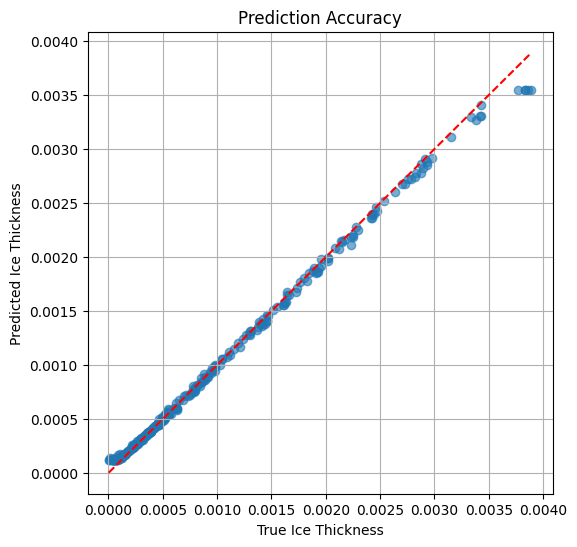

Skipping LWC=0.6, MVD=40: No data found in master_dataset.csv
Skipping LWC=0.8, MVD=40: No data found in master_dataset.csv


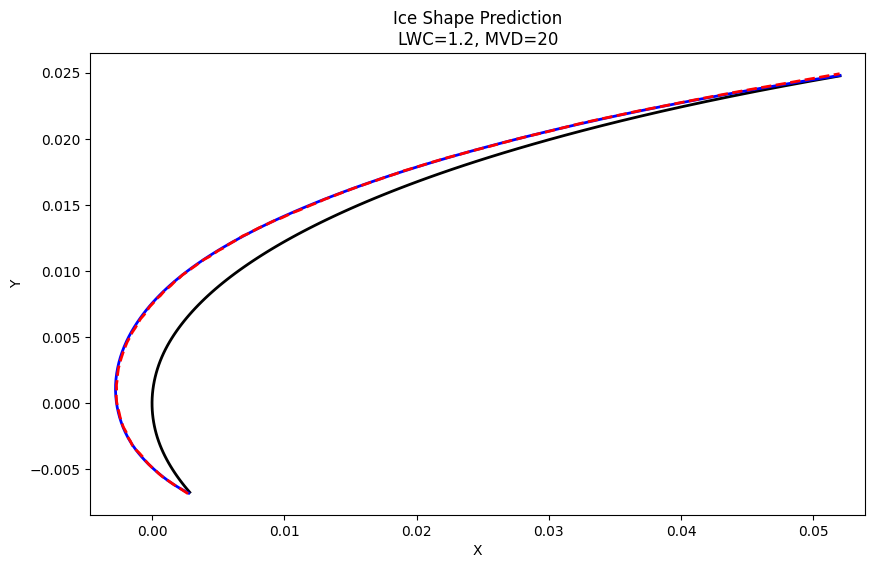

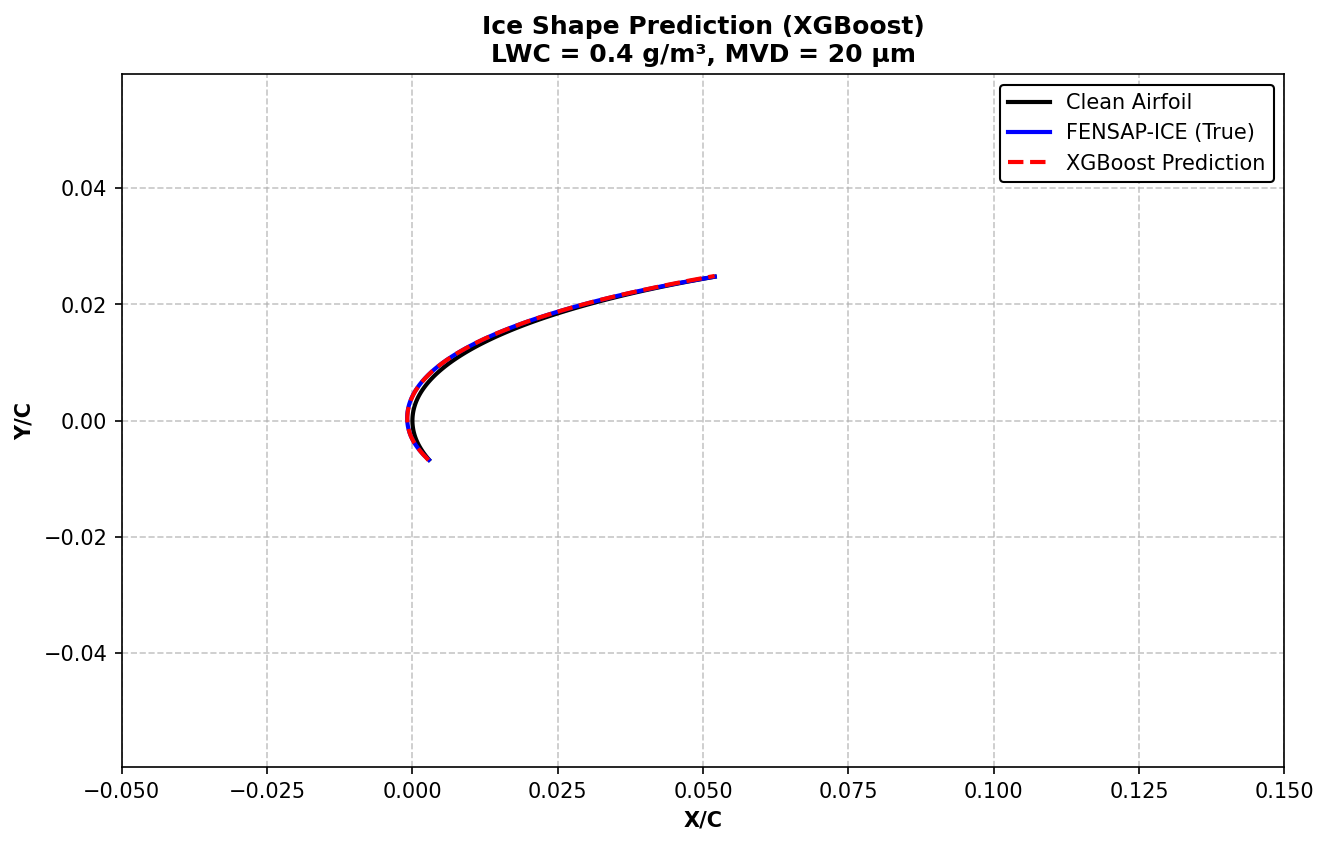

Successfully generated and saved: IceShape_LWC_0.4_MVD_20.png


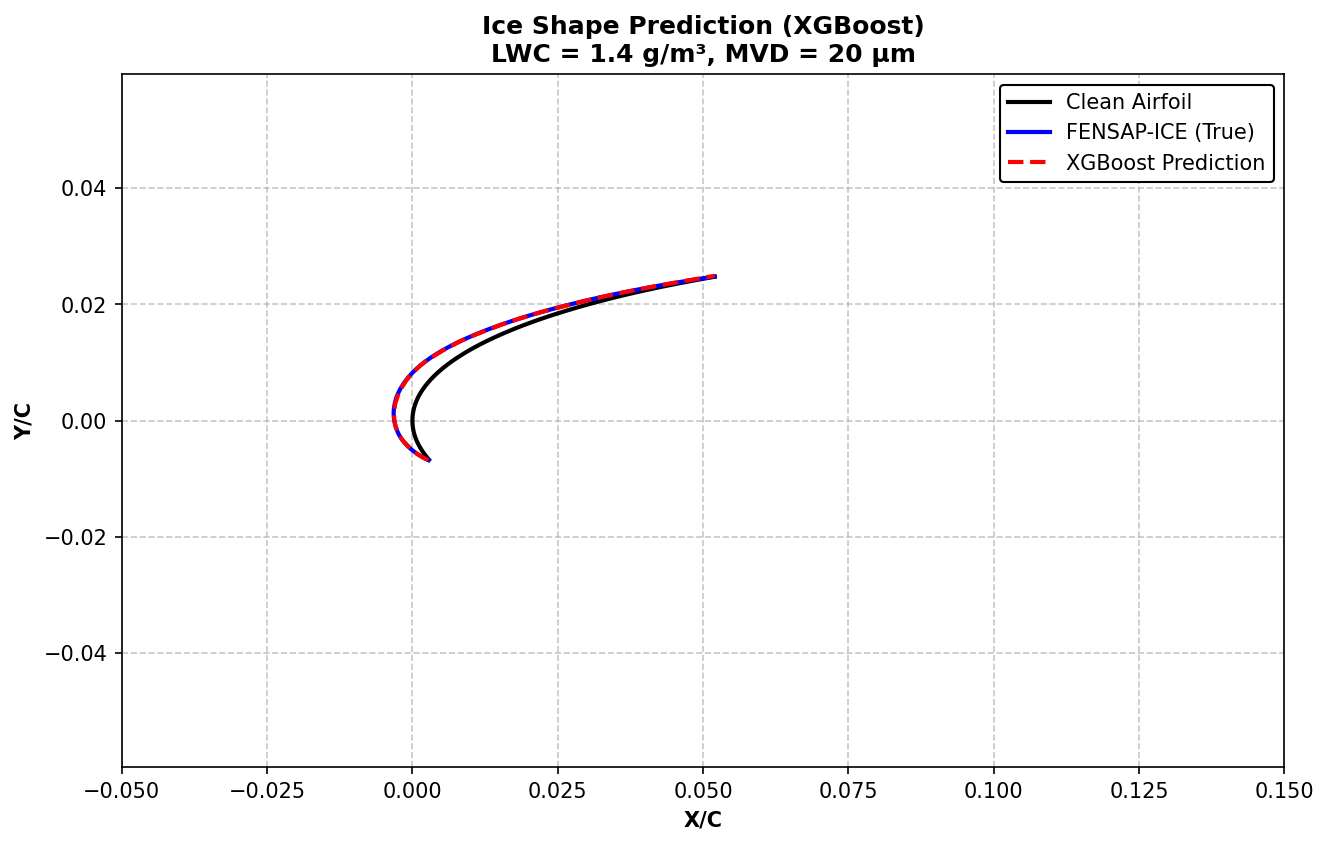

Successfully generated and saved: IceShape_LWC_1.4_MVD_20.png


/tmp/ipykernel_973/2689562618.py:304: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


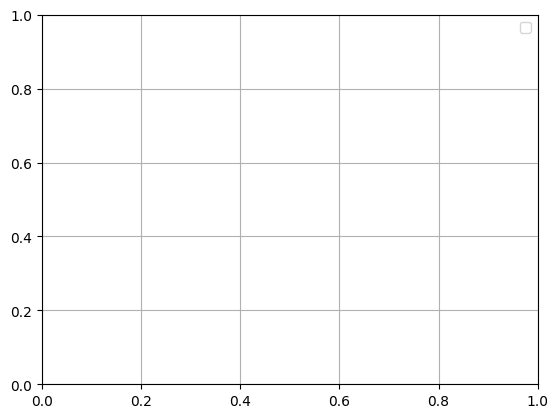

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor


# LOAD DATA


df = pd.read_csv("master_dataset.csv")

print(df.head())


features = [
    "xi",
    "eta",
    "LWC",
    "MVD",
    "MassCaught",
    "CollectionEfficiency",
    "Temperature"
]

target = "IceThickness"

X = df[features]
y = df[target]


scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# TRAIN TEST SPLIT


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)


# MODEL


model = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='reg:squarederror',
    random_state=42
)


# TRAIN


model.fit(X_train, y_train)


# PREDICT
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print("-----------------")
print("RMSE =", rmse)
print("R²   =", r2)



importance = pd.DataFrame({
    'Feature':features,
    'Importance':model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance")
print(importance)


# VISUALIZE

plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

plt.plot(lims, lims, 'r--')

plt.xlabel("True Ice Thickness")
plt.ylabel("Predicted Ice Thickness")

plt.title("Prediction Accuracy")

plt.grid(True)

plt.show()



LWC_CASE = 1.2
MVD_CASE = 20

case = df[
    (df["LWC"] == LWC_CASE)
    &
    (df["MVD"] == MVD_CASE)
].copy()



X_case = scaler.transform(
    case[features]
)

case["PredThickness"] = model.predict(X_case)



case = case.sort_values("xi")

Xc = case["X"].values
Yc = case["Y"].values

T_true = case["IceThickness"].values
T_pred = case["PredThickness"].values

dx = np.gradient(Xc)
dy = np.gradient(Yc)

length = np.sqrt(dx**2 + dy**2)

tx = dx/length
ty = dy/length

nx = -ty
ny = tx

X_true = Xc + nx*T_true
Y_true = Yc + ny*T_true

X_pred = Xc + nx*T_pred
Y_pred_shape = Yc + ny*T_pred
plt.figure(figsize=(10,6))

# clean airfoil

plt.plot(
    Xc,
    Yc,
    'k',
    linewidth=2,
    label="Airfoil"
)

# true

plt.plot(
    X_true,
    Y_true,
    'b',
    linewidth=2,
    label="FENSAP-ICE"
)

# predicted

plt.plot(
    X_pred,
    Y_pred_shape,
    'r--',
    linewidth=2,
    label="ML Prediction"
)

plt.axis('equal')

plt.xlabel("X")
plt.ylabel("Y")

plt.title(
    f"Ice Shape Prediction\n"
    f"LWC={LWC_CASE}, MVD={MVD_CASE}"
)

#FOR MULTIPLE CASES


# (LWC, MVD) plots
cases_to_plot = [
    (0.6, 40),
    (0.8, 40),
    (0.4, 20),
    (1.4, 20)
]

for lwc_case, mvd_case in cases_to_plot:
    #specific case
    case = df[(df["LWC"] == lwc_case) & (df["MVD"] == mvd_case)].copy()

    # Skip if the combination doesn't exist in the master dataset
    if case.empty:
        print(f"Skipping LWC={lwc_case}, MVD={mvd_case}: No data found in master_dataset.csv")
        continue

    #  Predict Ice Thickness
    X_case = scaler.transform(case[features])
    case["PredThickness"] = model.predict(X_case)


    case = case.sort_values("xi")

    Xc = case["X"].values
    Yc = case["Y"].values

    T_true = case["IceThickness"].values
    T_pred = case["PredThickness"].values


    dx = np.gradient(Xc)
    dy = np.gradient(Yc)

    length = np.sqrt(dx**2 + dy**2)


    length[length == 0] = 1e-8

    tx = dx / length
    ty = dy / length

    nx = -ty
    ny = tx


    X_true = Xc + nx * T_true
    Y_true = Yc + ny * T_true

    X_pred = Xc + nx * T_pred
    Y_pred_shape = Yc + ny * T_pred

    # 6. Generate the Plot
    plt.figure(figsize=(10, 6), dpi=150)

    # Clean Airfoil
    plt.plot(Xc, Yc, 'k', linewidth=2, label="Clean Airfoil")

    # True FENSAP-ICE Shape
    plt.plot(X_true, Y_true, 'b', linewidth=2, label="FENSAP-ICE (True)")

    # XGBoost Prediction
    plt.plot(X_pred, Y_pred_shape, 'r--', linewidth=2, label="XGBoost Prediction")

    # Formatting
    plt.axis('equal')
    plt.xlim([-0.05, 0.15]) # Zooms in on the leading edge (adjust if needed)
    plt.ylim([-0.06, 0.06])

    plt.xlabel("X/C", fontweight='bold')
    plt.ylabel("Y/C", fontweight='bold')
    plt.title(f"Ice Shape Prediction (XGBoost)\nLWC = {lwc_case} g/m³, MVD = {mvd_case} μm", fontweight='bold')

    plt.legend(loc='upper right', framealpha=1.0, edgecolor='black')
    plt.grid(True, linestyle='--', alpha=0.7)

    # 7. Save and Show
    filename = f"IceShape_LWC_{lwc_case}_MVD_{mvd_case}.png"
    plt.savefig(filename, bbox_inches='tight')
    plt.show()

    print(f"Successfully generated and saved: {filename}")
plt.legend()

plt.grid(True)

plt.show()

Training samples : 9997
LWC samples      : 920
MVD samples      : 724

Training model...


Results
RMSE = 2.1441215307239756e-05
R2   = 0.9973594530206438

Feature Importance

                Feature  Importance
5  CollectionEfficiency    0.405998
4            MassCaught    0.392273
2                   LWC    0.175315
1                   eta    0.026414
0           zeta_scaled    0.000000
3                   MVD    0.000000
6       WallTemperature    0.000000

Predicting LWC dataset...



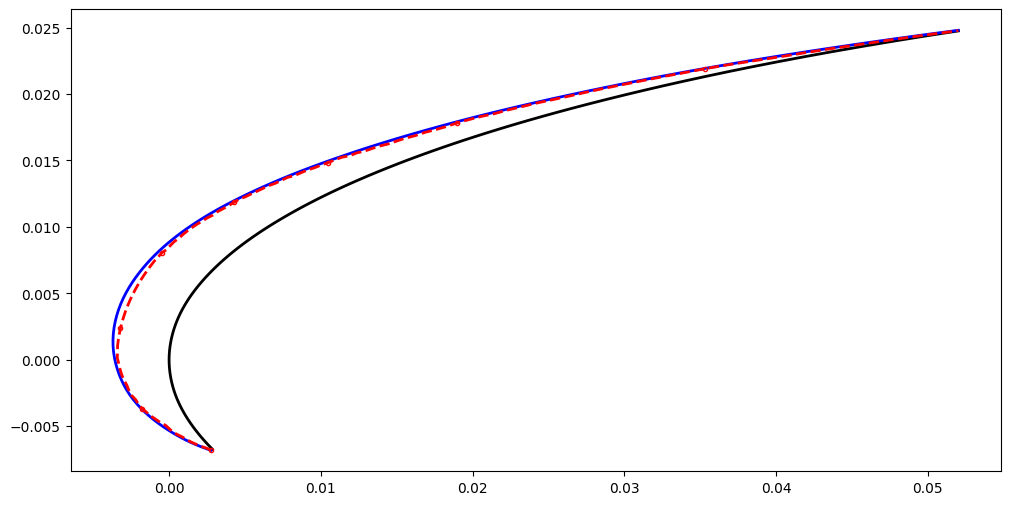

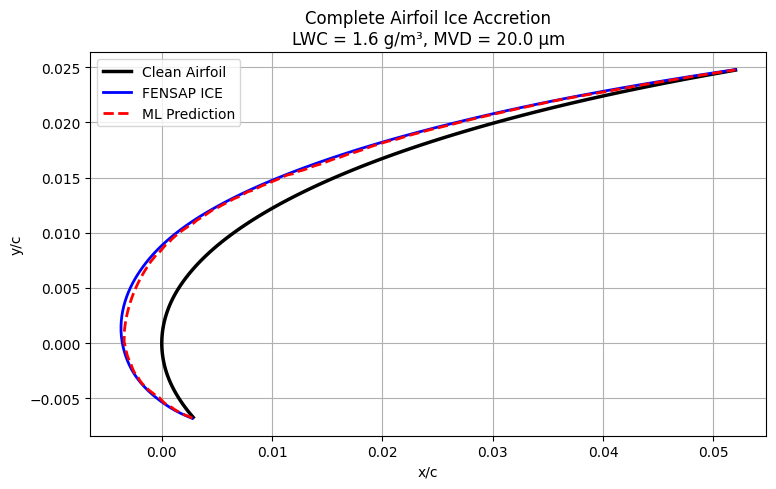

In [ ]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from scipy.ndimage import gaussian_filter1d

from xgboost import XGBRegressor


# LOAD DATA


train_df = pd.read_csv("master_dataset_full.csv")

lwc_df = pd.read_csv("master_dataset_LWC.csv")
mvd_df = pd.read_csv("master_dataset_MVD.csv")

print("Training samples :", len(train_df))
print("LWC samples      :", len(lwc_df))
print("MVD samples      :", len(mvd_df))



features = [

    "zeta_scaled",
    "eta",

    "LWC",
    "MVD",

    "MassCaught",
    "CollectionEfficiency",

    "WallTemperature"

]

target = "IceThickness"



train_df = train_df.fillna(0)

X = train_df[features]
y = train_df[target]



scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)



X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,
    y,

    test_size=0.2,
    random_state=42

)

# MODEL


model = XGBRegressor(

    n_estimators=1000,
    max_depth=10,

    learning_rate=0.03,

    subsample=0.9,
    colsample_bytree=0.9,

    objective="reg:squarederror",

    random_state=42

)

# TRAIN


print("\nTraining model...\n")

model.fit(

    X_train,
    y_train

)



pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("\nResults")
print("RMSE =", rmse)
print("R2   =", r2)


# FEATURE IMPORTANCE


importance = pd.DataFrame({

    "Feature": features,
    "Importance": model.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("\nFeature Importance\n")
print(importance)


print("\nPredicting LWC dataset...\n")

lwc_df = lwc_df.fillna(0)

X_lwc = scaler.transform(

    lwc_df[[
        "xi_scaled",
        "eta",
        "LWC",
        "MVD",
        "MassCaught",
        "CollectionEfficiency",
        "Temperature"
    ]].rename(columns={
        "xi_scaled":"zeta_scaled",
        "Temperature":"WallTemperature"
    })

)

lwc_df["PredThickness"] = model.predict(X_lwc)



case = lwc_df[

    (lwc_df["LWC"] == lwc_df["LWC"].max())

].copy()



case = case.sort_values("xi_scaled")

Xc = case["X"].values
Yc = case["Y"].values

T_true = case["IceThickness"].values
T_pred = case["PredThickness"].values


# SMOOTH NORMALS


Xs = gaussian_filter1d(Xc, sigma=2)
Ys = gaussian_filter1d(Yc, sigma=2)

dx = np.gradient(Xs)
dy = np.gradient(Ys)

length = np.sqrt(dx**2 + dy**2)

tx = dx / length
ty = dy / length

nx = -ty
ny = tx

# TRUE ICE SHAPE


X_true = Xc + nx*T_true
Y_true = Yc + ny*T_true


# PREDICTED ICE SHAPE


X_pred = Xc + nx*T_pred
Y_pred = Yc + ny*T_pred



plt.figure(figsize=(12,6))

# Airfoil

plt.plot(

    Xc,
    Yc,

    color='black',
    linewidth=2,

    label="Clean Airfoil"

)

# True

plt.plot(

    X_true,
    Y_true,

    color='blue',
    linewidth=2,

    label="FENSAP-ICE"

)

# Predicted

plt.plot(

    X_pred,
    Y_pred,

    'r--',

    linewidth=2,

    marker='o',
    markersize=3,
    markevery=15,

    fillstyle='none',

    label="ML Prediction"

)



plt.figure(figsize=(14,5))

# Clean Airfoil

plt.plot(
    Xc,
    Yc,
    color='black',
    linewidth=2.5,
    label='Clean Airfoil'
)

# True FENSAP Ice

plt.plot(
    X_true,
    Y_true,
    color='blue',
    linewidth=2,
    label='FENSAP ICE'
)

# ML Prediction

plt.plot(
    X_pred,
    Y_pred,
    'r--',
    linewidth=2,
    label='ML Prediction'
)

plt.gca().set_aspect('equal')

plt.xlabel("x/c")
plt.ylabel("y/c")

plt.title(
    f"Complete Airfoil Ice Accretion\n"
    f"LWC = {case['LWC'].iloc[0]} g/m³, "
    f"MVD = {case['MVD'].iloc[0]} μm"
)

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving LWC_0.4.csv to LWC_0.4.csv
Saving LWC_1.0.csv to LWC_1.0.csv
Saving LWC_1.2.csv to LWC_1.2.csv
Saving LWC_1.4.csv to LWC_1.4.csv
Saving LWC_1.6.csv to LWC_1.6.csv
Saving LWC_0.2.csv to LWC_0.2.csv
Saving LWC_0.2_ice_data.csv to LWC_0.2_ice_data.csv
Saving LWC_0.4_ice_data.csv to LWC_0.4_ice_data.csv
Saving LWC_0.6.csv to LWC_0.6.csv
Saving LWC_0.6_ice_data.csv to LWC_0.6_ice_data.csv
Saving LWC_0.8.csv to LWC_0.8.csv
Saving LWC_0.8_ice_data.csv to LWC_0.8_ice_data.csv
Saving LWC_1.0_ice_data.csv to LWC_1.0_ice_data.csv
Saving LWC_1.2_ice_data.csv to LWC_1.2_ice_data.csv
Saving LWC_1.4_ice_data.csv to LWC_1.4_ice_data.csv
Saving LWC_1.6_ice_data.csv to LWC_1.6_ice_data.csv
Saving mvd_10(iced).csv to mvd_10(iced).csv
Saving mvd_10.csv to mvd_10.csv
Saving mvd_15(iced).csv to mvd_15(iced).csv
Saving mvd_15.csv to mvd_15.csv
Saving mvd_20(ice).csv to mvd_20(ice).csv
Saving mvd_20.csv to mvd_20.csv
Saving mvd_25(iced).csv to mvd_25(iced).csv
Saving mvd_25.csv to mvd_25.csv
Saving mvd

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving master_dataset_full.csv to master_dataset_full.csv
Saving master_dataset.csv to master_dataset.csv
Saving master_dataset_LWC.csv to master_dataset_LWC.csv
Saving master_dataset_MVD.csv to master_dataset_MVD.csv
